In [1]:
# Import libraries for regression modeling
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

FIGURE_DIR = Path('../reports/figures')
if not FIGURE_DIR.exists():
    FIGURE_DIR = Path('reports/figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Load the processed regression data
data_path = '../data/processed/hotel_bookings_reg.csv'

if not os.path.exists(data_path):
    data_path = 'data/processed/hotel_bookings_reg.csv'

df = pd.read_csv(data_path)

print('Data path:', data_path)
print('Shape:', df.shape)
display(df.head())

Data path: ../data/processed/hotel_bookings_reg.csv
Shape: (73386, 83)


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,assigned_room_type_B,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L
0,0,7,2015,27,1,0,1,1,0.0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,13,2015,27,1,0,1,1,0.0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,14,2015,27,1,0,2,2,0.0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,14,2015,27,1,0,2,2,0.0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,2015,27,1,0,2,2,0.0,0,...,0,1,0,0,0,0,0,0,0,0


In [3]:
# Check target quality and basic data status
print('Missing values:', int(df.isnull().sum().sum()))
print('Object columns:', len(df.select_dtypes(include='object').columns))
print('is_canceled counts:')
print(df['is_canceled'].value_counts().sort_index())
print('\nADR summary:')
print(df['adr'].describe().round(3))

Missing values: 0
Object columns: 0
is_canceled counts:
is_canceled
0    73386
Name: count, dtype: int64

ADR summary:
count    73386.000
mean       102.373
std         47.222
min          0.260
25%         70.000
50%         94.500
75%        126.000
max        451.500
Name: adr, dtype: float64


In [4]:
# Prepare X and y for ADR prediction
target = 'adr'
assigned_cols = [col for col in df.columns if col.startswith('assigned_room_type_')]
drop_cols = [target, 'is_canceled'] + assigned_cols

X = df.drop(columns=drop_cols, errors='ignore')
y = df[target]

print('Target:', target)
print('Dropped columns:', len(drop_cols))
print('Assigned room columns removed:', len(assigned_cols))
print('Feature shape:', X.shape)
print('Target shape:', y.shape)

Target: adr
Dropped columns: 12
Assigned room columns removed: 10
Feature shape: (73386, 71)
Target shape: (73386,)


In [5]:
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('\nTrain ADR summary:')
print(y_train.describe().round(2))
print('\nTest ADR summary:')
print(y_test.describe().round(2))

Train shape: (58708, 71)
Test shape: (14678, 71)

Train ADR summary:
count    58708.00
mean       102.34
std         47.17
min          0.26
25%         69.97
50%         94.40
75%        126.00
max        451.50
Name: adr, dtype: float64

Test ADR summary:
count    14678.00
mean       102.50
std         47.42
min          1.00
25%         70.00
50%         94.67
75%        125.65
max        397.38
Name: adr, dtype: float64


In [6]:
# Build regression model and parameter combinations
models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Decision Tree depth 8': DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    'Decision Tree depth 12': DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE),
    'Decision Tree depth 16': DecisionTreeRegressor(max_depth=16, random_state=RANDOM_STATE),
    'Random Forest depth 14': RandomForestRegressor(
        n_estimators=50,
        max_depth=14,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}

print('Models:', list(models.keys()))
print('CV:', cv)

Models: ['Linear Regression', 'Decision Tree depth 8', 'Decision Tree depth 12', 'Decision Tree depth 16', 'Random Forest depth 14']
CV: KFold(n_splits=5, random_state=42, shuffle=True)


Running: Linear Regression


Running: Decision Tree depth 8


Running: Decision Tree depth 12


Running: Decision Tree depth 16


Running: Random Forest depth 14


,model,cv_mae,cv_mse,cv_rmse,cv_r2
4,Random Forest depth 14,11.9109,340.7130,18.4584,0.8469
3,Decision Tree depth 16,13.2756,509.5903,22.5741,0.7710
2,Decision Tree depth 12,15.2007,544.5843,23.3363,0.7553
1,Decision Tree depth 8,19.5132,757.5012,27.5227,0.6595
0,Linear Regression,21.0904,821.1745,28.6561,0.6309


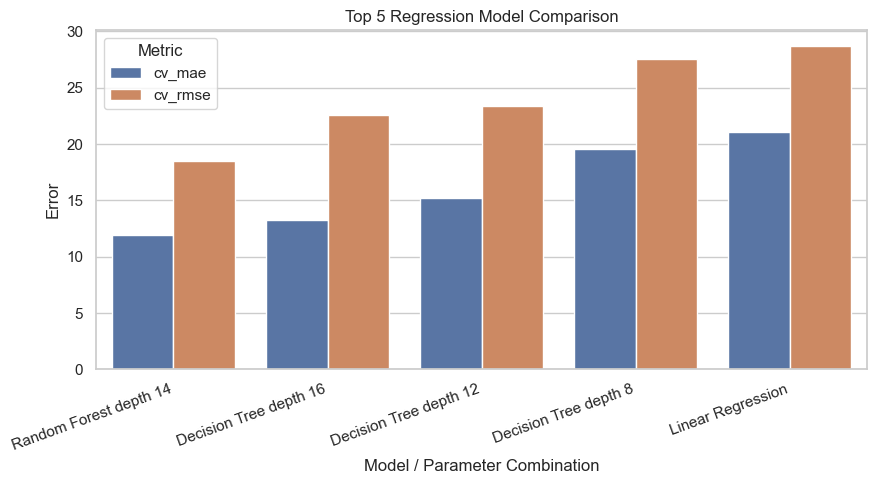

Saved figure: ..\reports\figures\regression_model_comparison.png


In [7]:
# Compare model combinations with 5-fold cross validation
cv_rows = []

for name, model in models.items():
    print('Running:', name)
    score = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    mae = -score['test_mae'].mean()
    mse = -score['test_mse'].mean()
    rmse = np.sqrt(mse)
    r2 = score['test_r2'].mean()
    cv_rows.append({
        'model': name,
        'cv_mae': mae,
        'cv_mse': mse,
        'cv_rmse': rmse,
        'cv_r2': r2
    })

cv_result = pd.DataFrame(cv_rows).sort_values('cv_rmse')
top5_result = cv_result.head(5)
display(top5_result.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = top5_result.melt(id_vars='model', value_vars=['cv_mae', 'cv_rmse'])
sns.barplot(data=plot_df, x='model', y='value', hue='variable', ax=ax)
ax.set_title('Top 5 Regression Model Comparison')
ax.set_xlabel('Model / Parameter Combination')
ax.set_ylabel('Error')
ax.legend(title='Metric')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
comparison_path = FIGURE_DIR / 'regression_model_comparison.png'
plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved figure:', comparison_path)

In [8]:
# Train the best regression model and evaluate it on the test data
best_name = cv_result.iloc[0]['model']
best_model = models[best_name]
safe_name = best_name.lower().replace(' ', '_')

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

test_result = pd.DataFrame([{
    'model': best_name,
    'test_mae': mae,
    'test_mse': mse,
    'test_rmse': rmse,
    'test_r2': r2
}])

print('Best model:', best_name)
display(test_result.round(4))

Best model: Random Forest depth 14


,model,test_mae,test_mse,test_rmse,test_r2
0,Random Forest depth 14,11.8832,348.7546,18.675,0.8449


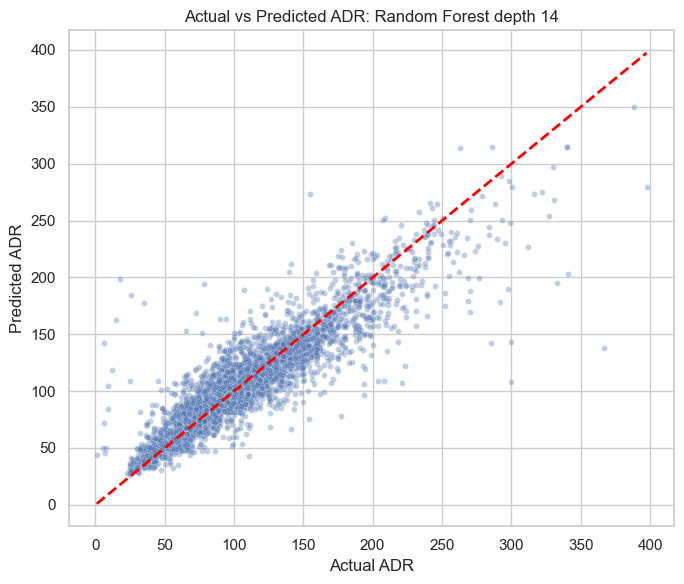

Saved figure: ..\reports\figures\regression_actual_vs_predicted.png


In [9]:
# Plot actual ADR against predicted ADR
pred_df = pd.DataFrame({
    'actual_adr': y_test,
    'predicted_adr': y_pred,
    'residual': y_test - y_pred
})

plot_sample = pred_df.sample(n=min(5000, len(pred_df)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=plot_sample, x='actual_adr', y='predicted_adr', alpha=0.35, s=18, ax=ax)
min_val = min(plot_sample['actual_adr'].min(), plot_sample['predicted_adr'].min())
max_val = max(plot_sample['actual_adr'].max(), plot_sample['predicted_adr'].max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
ax.set_title(f'Actual vs Predicted ADR: {best_name}')
ax.set_xlabel('Actual ADR')
ax.set_ylabel('Predicted ADR')
plt.tight_layout()
actual_pred_path = FIGURE_DIR / 'regression_actual_vs_predicted.png'
plt.savefig(actual_pred_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved figure:', actual_pred_path)

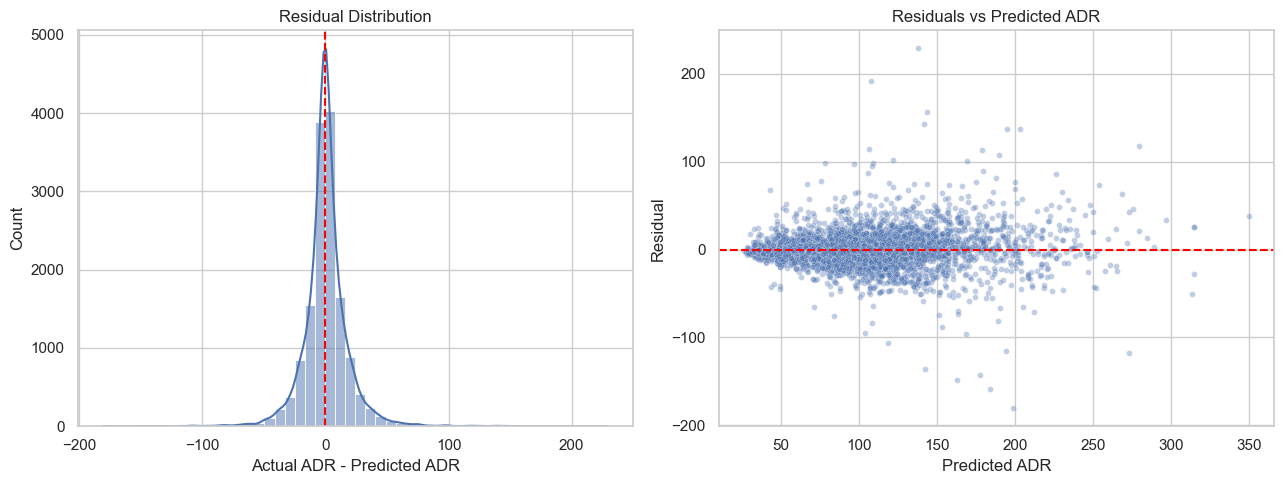

Saved figure: ..\reports\figures\regression_residual_analysis.png


In [10]:
# Analyze regression residuals
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(pred_df['residual'], bins=50, kde=True, ax=axes[0], color='#4C72B0')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Actual ADR - Predicted ADR')

sns.scatterplot(data=plot_sample, x='predicted_adr', y='residual', alpha=0.35, s=18, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted ADR')
axes[1].set_xlabel('Predicted ADR')
axes[1].set_ylabel('Residual')

plt.tight_layout()
residual_path = FIGURE_DIR / 'regression_residual_analysis.png'
plt.savefig(residual_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved figure:', residual_path)

,feature,importance
2,arrival_date_week_number,0.2427
16,total_guests,0.2220
21,hotel_Resort Hotel,0.1071
0,lead_time,0.0494
1,arrival_date_year,0.0446
23,meal_HB,0.0422
31,market_segment_Online TA,0.0391
28,market_segment_Direct,0.0378
42,arrival_date_month_August,0.0270
3,arrival_date_day_of_month,0.0239


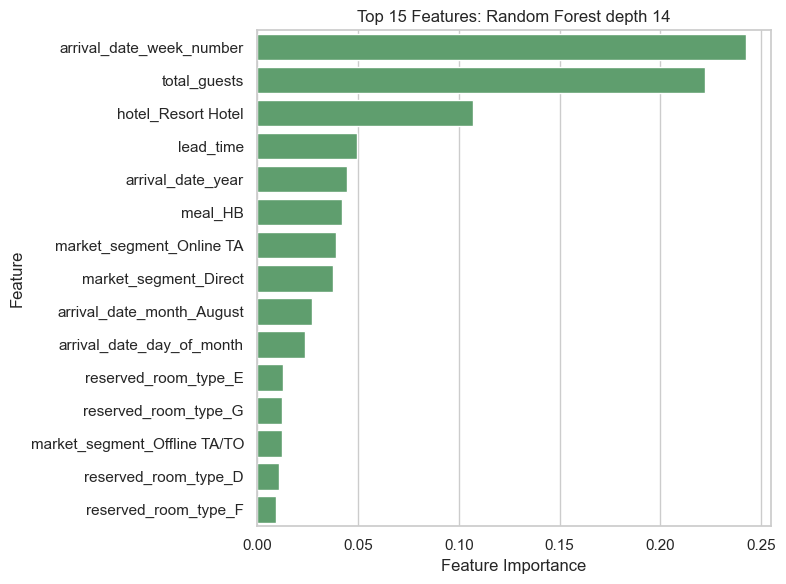

Saved figure: ..\reports\figures\regression_feature_importance.png


In [11]:
# Show important features from the selected regression model
model_part = best_model.named_steps['model'] if hasattr(best_model, 'named_steps') else best_model

if hasattr(model_part, 'feature_importances_'):
    importance = model_part.feature_importances_
    title = 'Feature Importance'
elif hasattr(model_part, 'coef_'):
    importance = np.abs(model_part.coef_)
    title = 'Absolute Coefficient'
else:
    importance = np.zeros(len(X.columns))
    title = 'Importance'

imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values('importance', ascending=False).head(15)

display(imp_df.round(4))

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=imp_df, x='importance', y='feature', ax=ax, color='#55A868')
ax.set_title(f'Top 15 Features: {best_name}')
ax.set_xlabel(title)
ax.set_ylabel('Feature')
plt.tight_layout()
importance_path = FIGURE_DIR / 'regression_feature_importance.png'
plt.savefig(importance_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved figure:', importance_path)

In [12]:
# Summarize the final regression result
print('Final selected model:', best_name)
print('Number of input features:', X.shape[1])
print('Excluded is_canceled:', 'is_canceled' in drop_cols)
print('Excluded assigned_room_type columns:', len(assigned_cols))
print('\nTop 5 CV combinations:')
print(top5_result.round(4).to_string(index=False))
print('\nTest scores:')
print(test_result.round(4).to_string(index=False))

Final selected model: Random Forest depth 14
Number of input features: 71
Excluded is_canceled: True
Excluded assigned_room_type columns: 10

Top 5 CV combinations:
                 model  cv_mae   cv_mse  cv_rmse  cv_r2
Random Forest depth 14 11.9109 340.7130  18.4584 0.8469
Decision Tree depth 16 13.2756 509.5903  22.5741 0.7710
Decision Tree depth 12 15.2007 544.5843  23.3363 0.7553
 Decision Tree depth 8 19.5132 757.5012  27.5227 0.6595
     Linear Regression 21.0904 821.1745  28.6561 0.6309

Test scores:
                 model  test_mae  test_mse  test_rmse  test_r2
Random Forest depth 14   11.8832  348.7546     18.675   0.8449
